# Trending Skills and Jobs Analysis Using NLP
## ITS120L Project

This notebook analyzes trending skills and jobs from LinkedIn job postings using Natural Language Processing techniques.

### Project Overview
- Dataset: LinkedIn Job Postings with Skills and Summaries
- Objective: Analyze trending skills and identify in-demand job roles
- Methods: Text processing, skill extraction, clustering, and topic modeling

## 1. Setup and Import Libraries

First, let's import all necessary libraries for data processing, NLP, and visualization.

In [1]:
# Data Processing
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
import re
import string

# Scikit-learn for ML and NLP
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [22]:
# Download required NLTK data
nltk_packages = ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'averaged_perceptron_tagger', 'maxent_ne_chunker', 'words']

for package in nltk_packages:
    try:
        nltk.download(package, quiet=True)
    except:
        print(f"Note: {package} download issue - continuing...")

print("NLTK packages downloaded")

NLTK packages downloaded


---
## 2. Data Loading and Initial Exploration

Load the three main datasets:
1. linkedin_job_postings.csv - Job metadata
2. job_skills.csv - Extracted skills per job
3. job_summary.csv - Job descriptions

In [3]:
# Define file paths
DATA_PATH = 'dataset/'

# Load datasets with proper encoding
print("Loading datasets...")
print("This may take a few moments due to large file sizes...\n")

# Load job postings (main dataset)
df_postings = pd.read_csv(DATA_PATH + 'linkedin_job_postings.csv', 
                          encoding='utf-8', 
                          low_memory=False)
print(f"Job Postings loaded: {len(df_postings):,} records")

# Load job skills
df_skills = pd.read_csv(DATA_PATH + 'job_skills.csv', 
                        encoding='utf-8', 
                        low_memory=False)
print(f"Job Skills loaded: {len(df_skills):,} records")

# Load job summaries
df_summary = pd.read_csv(DATA_PATH + 'job_summary.csv', 
                         encoding='utf-8', 
                         low_memory=False)
print(f"Job Summaries loaded: {len(df_summary):,} records")

print("\nAll datasets loaded successfully")

Loading datasets...
This may take a few moments due to large file sizes...

Job Postings loaded: 1,348,454 records
Job Skills loaded: 1,296,381 records
Job Summaries loaded: 1,297,332 records

All datasets loaded successfully


In [4]:
# Display basic information about each dataset
print("="*70)
print("DATASET OVERVIEW")
print("="*70)

print("\n1. JOB POSTINGS DATASET:")
print("-" * 50)
print(f"Shape: {df_postings.shape}")
print(f"\nColumns: {list(df_postings.columns)}")
print(f"\nMemory Usage: {df_postings.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n2. JOB SKILLS DATASET:")
print("-" * 50)
print(f"Shape: {df_skills.shape}")
print(f"\nColumns: {list(df_skills.columns)}")

print("\n3. JOB SUMMARY DATASET:")
print("-" * 50)
print(f"Shape: {df_summary.shape}")
print(f"\nColumns: {list(df_summary.columns)}")

DATASET OVERVIEW

1. JOB POSTINGS DATASET:
--------------------------------------------------
Shape: (1348454, 14)

Columns: ['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']

Memory Usage: 1225.80 MB

2. JOB SKILLS DATASET:
--------------------------------------------------
Shape: (1296381, 2)

Columns: ['job_link', 'job_skills']

3. JOB SUMMARY DATASET:
--------------------------------------------------
Shape: (1297332, 2)

Columns: ['job_link', 'job_summary']


In [13]:
# Preview the datasets
print("="*70)
print("SAMPLE DATA")
print("="*70)

print("\nJob Postings Sample:")
display(df_postings.head(3))

print("\nJob Skills Sample:")
display(df_skills.head(3))

print("\nJob Summary Sample:")
display(df_summary.head(3))

SAMPLE DATA

Job Postings Sample:


,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/account-exe...,2024-01-21 07:12:29.00256+00,t,t,f,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 07:39:58.88137+00,t,t,f,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/restaurant-...,2024-01-21 07:40:00.251126+00,t,t,f,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite



Job Skills Sample:


,job_link,job_skills
0,https://www.linkedin.com/jobs/view/housekeeper...,"Building Custodial Services, Cleaning, Janitor..."
1,https://www.linkedin.com/jobs/view/assistant-g...,"Customer service, Restaurant management, Food ..."
2,https://www.linkedin.com/jobs/view/school-base...,"Applied Behavior Analysis (ABA), Data analysis..."



Job Summary Sample:


,job_link,job_summary
0,https://www.linkedin.com/jobs/view/restaurant-...,Rock N Roll Sushi is hiring a Restaurant Manag...
1,https://www.linkedin.com/jobs/view/med-surg-re...,Schedule\n: PRN is required minimum 12 hours p...
2,https://www.linkedin.com/jobs/view/registered-...,Description\nIntroduction\nAre you looking for...


### 2.1 Data Quality Assessment

In [23]:
# Check for missing values
print("="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

print("\n1. Job Postings:")
missing_postings = df_postings.isnull().sum()
missing_postings_pct = (missing_postings / len(df_postings) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_postings,
    'Percentage': missing_postings_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

print("\n2. Job Skills:")
print(f"Missing skills: {df_skills['job_skills'].isnull().sum()}")

print("\n3. Job Summary:")
print(f"Missing summaries: {df_summary['job_summary'].isnull().sum()}")

MISSING VALUES ANALYSIS

1. Job Postings:
              Missing Count  Percentage
job_location             19         0.0
company                  11         0.0

2. Job Skills:
Missing skills: 2085

3. Job Summary:
Missing summaries: 0


### 2.2 Merge Datasets

Combine all three datasets using job_link as the key.

In [24]:
# Merge datasets
print("Merging datasets on 'job_link'...\n")

# First merge: postings + skills
df = df_postings.merge(df_skills, on='job_link', how='left')
print(f"After merging postings + skills: {len(df):,} records")

# Second merge: add summaries
df = df.merge(df_summary, on='job_link', how='left')
print(f"After merging all datasets: {len(df):,} records")

print(f"\nFinal dataset shape: {df.shape}")
print(f"Total columns: {len(df.columns)}")

# Display merged dataset info
print("\n" + "="*70)
print("MERGED DATASET COLUMNS:")
print("="*70)
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Merging datasets on 'job_link'...

After merging postings + skills: 1,348,454 records
After merging all datasets: 1,348,454 records

Final dataset shape: (1348454, 16)
Total columns: 16

MERGED DATASET COLUMNS:
1. job_link
2. last_processed_time
3. got_summary
4. got_ner
5. is_being_worked
6. job_title
7. company
8. job_location
9. first_seen
10. search_city
11. search_country
12. search_position
13. job_level
14. job_type
15. job_skills
16. job_summary


In [25]:
# Preview merged dataset
print("\nMerged Dataset Sample:")
display(df[['job_title', 'company', 'job_location', 'job_level', 'job_type', 'job_skills']].head())


Merged Dataset Sample:


,job_title,company,job_location,job_level,job_type,job_skills
0,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",Mid senior,Onsite,"Medical equipment sales, Key competitors, Term..."
1,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",Mid senior,Onsite,"Nursing, Bachelor of Science in Nursing, Maste..."
2,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",Mid senior,Onsite,"Restaurant Operations Management, Inventory Ma..."
3,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",Mid senior,Onsite,"Real Estate, Customer Service, Sales, Negotiat..."
4,Group/Unit Supervisor (Systems Support Manager...,"IRS, Office of Chief Counsel","Chamblee, GA",Mid senior,Onsite,NaN


---
## 3. Exploratory Data Analysis

Analyzing the job market to identify trending jobs and patterns.

### 3.1 Trending Jobs Distribution

In [26]:
# Job Market Overview
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Job Level Distribution', 'Job Type Distribution', 
                    'Top 15 Companies', 'Top 15 Locations'),
    specs=[[{'type': 'bar'}, {'type': 'pie'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

# Job Level
job_level_counts = df['job_level'].value_counts().head(10)
fig.add_trace(
    go.Bar(x=job_level_counts.index, y=job_level_counts.values, 
           marker_color='indianred', name='Job Level'),
    row=1, col=1
)

# Job Type
job_type_counts = df['job_type'].value_counts()
fig.add_trace(
    go.Pie(labels=job_type_counts.index, values=job_type_counts.values, 
           name='Job Type'),
    row=1, col=2
)

# Top Companies
top_companies = df['company'].value_counts().head(15)
fig.add_trace(
    go.Bar(x=top_companies.values, y=top_companies.index, 
           orientation='h', marker_color='lightblue', name='Companies'),
    row=2, col=1
)

# Top Locations
top_locations = df['job_location'].value_counts().head(15)
fig.add_trace(
    go.Bar(x=top_locations.values, y=top_locations.index, 
           orientation='h', marker_color='lightgreen', name='Locations'),
    row=2, col=2
)

fig.update_layout(height=900, showlegend=False, title_text="Job Market Overview")
fig.show()

# Print statistics
print("\nJob Market Statistics:")
print("=" * 50)
print(f"Total job postings: {len(df):,}")
print(f"Unique companies: {df['company'].nunique():,}")
print(f"Unique locations: {df['job_location'].nunique():,}")
print(f"Unique job titles: {df['job_title'].nunique():,}")


Job Market Statistics:
Total job postings: 1,348,454
Unique companies: 90,605
Unique locations: 29,153
Unique job titles: 584,544


### 3.2 Geographic Distribution

In [27]:
# Country distribution
country_dist = df['search_country'].value_counts().head(20)

fig = px.bar(x=country_dist.values, y=country_dist.index, 
             orientation='h',
             title='Top 20 Countries by Job Postings',
             labels={'x': 'Number of Jobs', 'y': 'Country'},
             color=country_dist.values,
             color_continuous_scale='Viridis')
fig.update_layout(height=600, showlegend=False)
fig.show()

# City distribution
city_dist = df['search_city'].value_counts().head(20)

fig = px.treemap(names=city_dist.index, 
                 parents=[''] * len(city_dist),
                 values=city_dist.values,
                 title='Top 20 Cities - Job Distribution (Treemap)')
fig.update_layout(height=600)
fig.show()

---
## 4. Text Preprocessing

Initialize NLP tools and preprocess the job descriptions and skills.

In [28]:
# Initialize NLP tools
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Add custom stop words for job postings
custom_stop_words = {
    'job', 'work', 'position', 'role', 'opportunity', 'candidate', 'apply',
    'experience', 'year', 'years', 'will', 'must', 'required', 'preferred'
}
stop_words.update(custom_stop_words)

def clean_text(text):
    """
    Clean and preprocess text data.
    
    Args:
        text: Input text string
        
    Returns:
        Cleaned text string
    """
    if pd.isna(text):
        return ''
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def tokenize_and_lemmatize(text):
    """
    Tokenize and lemmatize text, removing stop words.
    
    Args:
        text: Input text string
        
    Returns:
        List of processed tokens
    """
    if not text:
        return []
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stop words and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens 
              if token not in stop_words and len(token) > 2]
    
    return tokens

def preprocess_pipeline(text):
    """
    Complete preprocessing pipeline.
    
    Args:
        text: Input text string
        
    Returns:
        Cleaned and processed text string
    """
    cleaned = clean_text(text)
    tokens = tokenize_and_lemmatize(cleaned)
    return ' '.join(tokens)

print("Text preprocessing functions defined")

Text preprocessing functions defined


In [29]:
# Apply preprocessing to job summaries
print("Processing job summaries...")
print("This may take several minutes for large datasets...\n")

# Sample for testing (remove sample() for full dataset)
df_sample = df.sample(n=min(10000, len(df)), random_state=42).copy()

# Process summaries
df_sample['cleaned_summary'] = df_sample['job_summary'].apply(preprocess_pipeline)

# Process skills separately (they're already structured)
df_sample['cleaned_skills'] = df_sample['job_skills'].apply(lambda x: clean_text(x) if pd.notna(x) else '')

# Combine summary and skills for comprehensive text
df_sample['combined_text'] = df_sample['cleaned_summary'] + ' ' + df_sample['cleaned_skills']

# Remove empty records
df_sample = df_sample[df_sample['combined_text'].str.strip() != '']

# Reset index after filtering
df_sample = df_sample.reset_index(drop=True)

print("Preprocessing complete")
print(f"Records with valid text: {len(df_sample):,}")

# Show example
print("\n" + "="*70)
print("PREPROCESSING EXAMPLE")
print("="*70)
sample_idx = 0
print(f"\nOriginal Summary (first 500 chars):")
print(df_sample['job_summary'].iloc[sample_idx][:500] if pd.notna(df_sample['job_summary'].iloc[sample_idx]) else "N/A")
print(f"\nCleaned Text (first 500 chars):")
print(df_sample['combined_text'].iloc[sample_idx][:500])

Processing job summaries...
This may take several minutes for large datasets...



Preprocessing complete
Records with valid text: 9,628

PREPROCESSING EXAMPLE

Original Summary (first 500 chars):
Registered Nurse (RN)Job Ref:191345Location:Vancouver, WA 98664Category:NursingLine of Business:PDSPay Rate:$33.00 - $38.00 per hourApplyRefer a FriendBackFind yourself here. Aveanna is compassion and passion rolled into one inspired purpose. It's anything you want to find and everything you're looking for. It's a place where caring is more personal, because it happens right in the comfort of home. Come see what's waiting for you when you come to Aveanna.Caring In ActionRN Responsibilities Inclu

Cleaned Text (first 500 chars):
registered nurse ref location vancouver category nursingline business pdspay rate per hourapplyrefer friendbackfind aveanna compassion passion rolled one inspired purpose anything want find everything looking place caring personal happens right comfort home come see waiting come aveanna caring actionrn responsibility include execution physician presc

---
## 5. Trending Skills Analysis

Extracting and analyzing the most in-demand skills from job postings.

In [58]:
# Extract meaningful technical skills only
from collections import Counter
import re

# Exclude vague phrases (soft skills, benefits, credentials, general terms)
vague_exclusions = {
    # Soft skills / generic competencies
    'problem solving', 'attention to detail', 'critical thinking',
    'conflict resolution', 'decision making', 'strategic thinking',
    'communication skills', 'interpersonal skills', 'organizational skills',
    'time management', 'leadership', 'communication', 'teamwork',
    
    # Benefits / perks (not skills)
    'paid time off', 'life insurance', 'medical insurance', 'dental insurance',
    'vision insurance', 'tuition reimbursement', '401k', 'health insurance',
    
    # Credentials / requirements (not learned skills)
    'bachelor', 'bachelors', 'bachelor degree', 'bachelor s degree',
    'high school diploma', 'driver s license', 'valid driver s license',
    
    # Generic business terms without specificity
    'quality control', 'quality assurance', 'quality', 'compliance',
    'regulatory compliance', 'safety compliance', 'regulatory',
    'procurement', 'management', 'operations', 'administration',
    'customer service', 'support', 'service', 'business',
    
    # Vague healthcare/general terms
    'patient assessment', 'patient safety', 'patient education',
    'nursing process', 'patient care', 'care', 'nursing care'
}

# Vague single tokens to exclude
vague_tokens = {
    'care', 'inventory', 'time', 'management', 'leadership', 'communication',
    'skill', 'skills', 'experience', 'bachelor', 'bachelors', 'degree',
    'business', 'support', 'service', 'services', 'operations', 'team',
    'associate', 'preferred', 'required', 'school', 'diploma', 'license',
    'paid', 'off', 'insurance', 'dental', 'vision', 'tuition', 'reimbursement',
    'opportunity', 'environment', 'professional', 'independently', 'equivalent',
    'quality', 'compliance', 'regulatory', 'procurement', 'safety', 'process',
    'assessment', 'education', 'patient', 'nursing'
}

# Concrete technical skills - programming, tools, technologies, methods
technical_skills = {
    # Programming languages
    'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'ruby', 'php',
    'go', 'rust', 'swift', 'kotlin', 'scala', 'r', 'matlab', 'sas',
    
    # Data & Analytics tools
    'sql', 'mysql', 'postgresql', 'oracle', 'mongodb', 'redis', 'cassandra',
    'snowflake', 'bigquery', 'redshift', 'spark', 'hadoop', 'hive', 'kafka',
    'tableau', 'powerbi', 'power bi', 'looker', 'qlik', 'excel', 'pandas',
    'numpy', 'scipy', 'matplotlib', 'seaborn', 'plotly',
    
    # Machine Learning / AI
    'machine learning', 'deep learning', 'tensorflow', 'pytorch', 'keras',
    'scikit learn', 'nlp', 'computer vision', 'neural networks',
    
    # Cloud & DevOps
    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'jenkins', 'gitlab',
    'terraform', 'ansible', 'chef', 'puppet', 'ci cd', 'devops',
    
    # Web & Mobile
    'react', 'angular', 'vue', 'node.js', 'node', 'express', 'django',
    'flask', 'spring', 'asp.net', 'html', 'css', 'sass', 'bootstrap',
    'jquery', 'webpack', 'rest api', 'graphql', 'microservices',
    
    # Systems & Infrastructure
    'linux', 'unix', 'windows server', 'bash', 'powershell', 'networking',
    'tcp ip', 'dns', 'dhcp', 'vpn', 'firewall', 'load balancing',
    
    # Security
    'cybersecurity', 'penetration testing', 'encryption', 'ssl', 'tls',
    'oauth', 'sso', 'iam', 'vulnerability assessment',
    
    # Version control & Collaboration
    'git', 'github', 'gitlab', 'bitbucket', 'svn', 'jira', 'confluence',
    
    # Design & Creative
    'photoshop', 'illustrator', 'figma', 'sketch', 'adobe xd', 'indesign',
    'autocad', 'solidworks', 'maya', '3ds max', 'blender',
    
    # Business & Finance tools
    'quickbooks', 'sap', 'oracle erp', 'salesforce', 'hubspot', 'dynamics 365',
    'financial modeling', 'financial analysis', 'bookkeeping', 'accounting software',
    
    # Medical / Technical certifications
    'cpr', 'acls', 'bls', 'pals', 'emr', 'ehr', 'epic', 'cerner', 'meditech',
    'phlebotomy', 'iv therapy', 'medication administration', 'ekg', 'ecg',
    
    # Statistical & Mathematical
    'statistics', 'statistical analysis', 'regression', 'hypothesis testing',
    'data modeling', 'forecasting', 'optimization',
    
    # Other technical
    'etl', 'data warehousing', 'database design', 'api development',
    'test automation', 'selenium', 'junit', 'pytest', 'unit testing',
    'agile', 'scrum', 'kanban', 'waterfall', 'sdlc'
}


def normalize_skill(skill):
    if pd.isna(skill):
        return ''
    skill = str(skill).lower().strip()
    skill = re.sub(r'[^a-z0-9\+#\.\-\s]', ' ', skill)
    skill = re.sub(r'\s+', ' ', skill).strip()
    return skill


def is_technical_skill(skill):
    if not skill or len(skill) < 2:
        return False
    
    # Exclude if in vague exclusion list
    if skill in vague_exclusions:
        return False
    
    # Exclude credential/benefit phrases
    if any(term in skill for term in ['bachelor', 'degree', 'diploma', 'license', 'insurance', 'paid time']):
        return False
    
    # Check if it's in the technical skills whitelist
    if skill in technical_skills:
        return True
    
    # For multi-word skills, check if they contain technical terms
    tokens = skill.split()
    
    # Single-word: must be in technical list
    if len(tokens) == 1:
        return tokens[0] in technical_skills
    
    # Multi-word: check if it contains technical components
    # and is not mostly vague tokens
    has_technical = any(token in technical_skills or skill in technical_skills for token in tokens)
    vague_count = sum(1 for token in tokens if token in vague_tokens)
    
    # Reject if mostly vague or no technical content
    if vague_count >= len(tokens) - 1:
        return False
    
    if not has_technical:
        return False
    
    # Reject overly long phrases
    if len(tokens) > 5:
        return False
    
    return True


def extract_technical_skills(skills_str):
    parsed = [normalize_skill(skill) for skill in str(skills_str).split(',')]
    filtered = [skill for skill in parsed if is_technical_skill(skill)]
    return filtered


# Parse and filter to technical skills only
raw_skill_mentions = 0
all_skills = []

for skills_str in df_sample['job_skills'].dropna():
    raw_list = [normalize_skill(skill) for skill in str(skills_str).split(',')]
    raw_skill_mentions += len([s for s in raw_list if s])
    
    technical_skills_filtered = extract_technical_skills(skills_str)
    all_skills.extend(technical_skills_filtered)

# Count skill frequency
skill_counts = Counter(all_skills)
top_skills = skill_counts.most_common(50)

print("\nTrending Technical Skills Analysis (Hard Skills Only)")
print("=" * 70)
print(f"Raw skill mentions: {raw_skill_mentions:,}")
print(f"Filtered technical skill mentions: {len(all_skills):,}")
print(f"Removed soft skills/benefits/vague terms: {raw_skill_mentions - len(all_skills):,}")
print(f"Total unique technical skills: {len(skill_counts):,}")
print(f"Average technical skills per job: {len(all_skills) / len(df_sample):.1f}")
print(f"\nTop 20 Most In-Demand Technical Skills:")
print("-" * 70)
for i, (skill, count) in enumerate(top_skills[:20], 1):
    print(f"{i:2d}. {skill:<40} ({count:,} jobs)")


Trending Technical Skills Analysis (Hard Skills Only)
Raw skill mentions: 199,898
Filtered technical skill mentions: 7,469
Removed soft skills/benefits/vague terms: 192,429
Total unique technical skills: 1,346
Average technical skills per job: 0.8

Top 20 Most In-Demand Technical Skills:
----------------------------------------------------------------------
 1. excel                                    (306 jobs)
 2. bls                                      (221 jobs)
 3. cpr                                      (202 jobs)
 4. microsoft excel                          (189 jobs)
 5. acls                                     (176 jobs)
 6. bls certification                        (172 jobs)
 7. python                                   (170 jobs)
 8. sql                                      (152 jobs)
 9. cpr certification                        (151 jobs)
10. medication administration                (151 jobs)
11. financial analysis                       (146 jobs)
12. networking         

In [59]:
# Visualize top skills
top_50_skills = pd.DataFrame(top_skills[:50], columns=['Skill', 'Count'])

fig = px.bar(top_50_skills, x='Count', y='Skill', 
             orientation='h',
             title='Top 50 Most In-Demand Skills',
             labels={'Count': 'Number of Job Postings', 'Skill': ''},
             color='Count',
             color_continuous_scale='Blues')
fig.update_layout(height=1000, yaxis={'categoryorder': 'total ascending'})
fig.show()

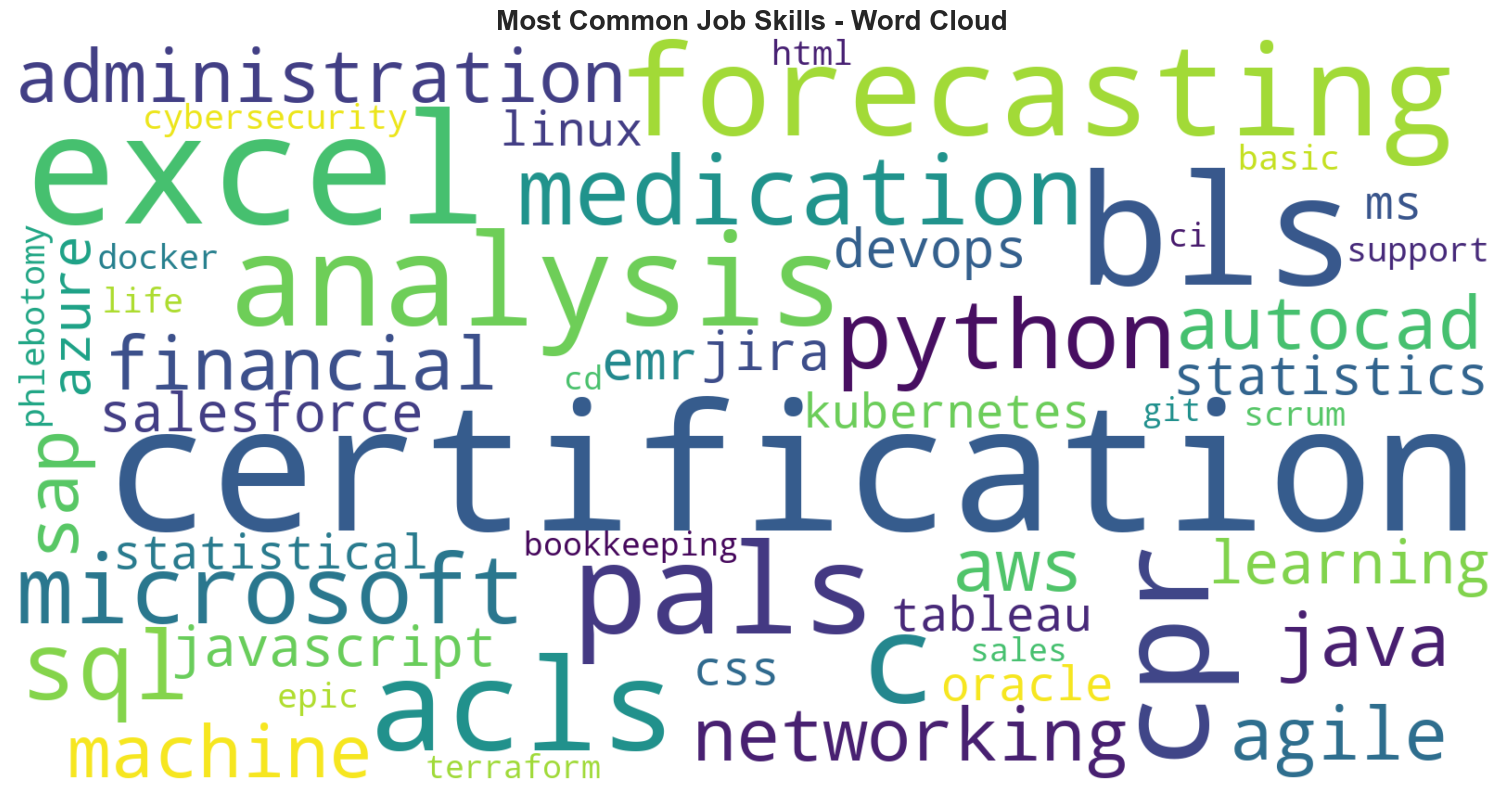

In [65]:
# Create word cloud of skills
skills_text = ' '.join([skill for skill, _ in top_skills[:100]])

plt.figure(figsize=(16, 8))
wordcloud = WordCloud(width=1600, height=800, 
                     background_color='white',
                     colormap='viridis',
                     max_words=100).generate(skills_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most Common Job Skills - Word Cloud', fontsize=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# Note: Filter out filler words that don't mean a thing such as 'skills', 'communication', etc.

### 5.1 Trending Skills by Job Level

In [66]:
# Analyze technical skills by job level
def get_top_skills_by_level(df, job_level, top_n=10):
    """
    Get top technical skills for a specific job level.
    """
    level_df = df[df['job_level'] == job_level]
    skills = []
    
    for skills_str in level_df['job_skills'].dropna():
        technical_skills_filtered = extract_technical_skills(skills_str)
        skills.extend(technical_skills_filtered)
    
    skill_counts = Counter(skills)
    return skill_counts.most_common(top_n)

# Get top job levels
top_levels = df_sample['job_level'].value_counts().head(4).index

print("\nTop Technical Skills by Job Level:")
print("=" * 70)

for level in top_levels:
    print(f"\n{level}:")
    print("-" * 50)
    top_level_skills = get_top_skills_by_level(df_sample, level, top_n=10)
    for i, (skill, count) in enumerate(top_level_skills, 1):
        print(f"  {i}. {skill} ({count})")


Top Technical Skills by Job Level:

Mid senior:
--------------------------------------------------
  1. excel (257)
  2. bls (212)
  3. cpr (187)
  4. acls (164)
  5. bls certification (164)
  6. microsoft excel (156)
  7. python (155)
  8. medication administration (148)
  9. cpr certification (138)
  10. sql (137)

Associate:
--------------------------------------------------
  1. excel (49)
  2. microsoft excel (33)
  3. sap (23)
  4. networking (21)
  5. autocad (16)
  6. cpr (15)
  7. python (15)
  8. sql (15)
  9. financial analysis (14)
  10. cpr certification (13)


---
## 6. TF-IDF Analysis

Using TF-IDF to identify the most important terms in job descriptions.

In [67]:
# Create TF-IDF vectorizer
print("Creating TF-IDF features...\n")

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),  # Include bigrams
    stop_words='english'
)

# Fit and transform
tfidf_matrix = tfidf_vectorizer.fit_transform(df_sample['combined_text'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Number of features: {len(feature_names):,}")

Creating TF-IDF features...

TF-IDF matrix shape: (9628, 5000)
Number of features: 5,000


In [68]:
# Get top TF-IDF terms (filtered to technical skills only)
def get_top_tfidf_terms(tfidf_matrix, feature_names, top_n=20):
    """
    Get the terms with highest average TF-IDF scores, filtered to technical skills only.
    """
    # Calculate mean TF-IDF for each term
    mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
    
    # Create list of all terms with scores
    all_terms = [(feature_names[i], mean_tfidf[i]) for i in range(len(feature_names))]
    
    # Sort by score
    all_terms.sort(key=lambda x: x[1], reverse=True)
    
    # Filter to only technical skills
    filtered_terms = []
    for term, score in all_terms:
        # Normalize the term
        normalized_term = normalize_skill(term)
        
        # Check if it's a technical skill
        if is_technical_skill(normalized_term):
            filtered_terms.append((term, score))
            
            # Stop when we have enough
            if len(filtered_terms) >= top_n:
                break
    
    return pd.DataFrame(filtered_terms, columns=['Term', 'TF-IDF Score'])

# Get and display top technical terms only
top_tfidf = get_top_tfidf_terms(tfidf_matrix, feature_names, top_n=30)

print("\nTop 30 Technical TF-IDF Terms (Filtered)")
print("=" * 70)
print(top_tfidf.to_string(index=False))

# Visualize
fig = px.bar(top_tfidf, x='TF-IDF Score', y='Term', 
             orientation='h',
             title='Top 30 Technical Terms by TF-IDF Score (Filtered)',
             color='TF-IDF Score',
             color_continuous_scale='Viridis')
fig.update_layout(height=700, yaxis={'categoryorder': 'total ascending'})
fig.show()


Top 30 Technical TF-IDF Terms (Filtered)
              Term  TF-IDF Score
             excel      0.006314
               bls      0.005589
               cpr      0.004428
              acls      0.003579
              epic      0.003053
              chef      0.002828
             agile      0.002785
               sql      0.002699
               sap      0.002563
        word excel      0.002284
               aws      0.002225
        networking      0.002199
            python      0.002103
 bls certification      0.002092
             azure      0.002060
 cpr certification      0.001952
               emr      0.001783
       forecasting      0.001777
        salesforce      0.001745
            oracle      0.001717
              java      0.001681
           autocad      0.001577
      optimization      0.001543
   microsoft excel      0.001477
financial analysis      0.001329
  excel powerpoint      0.001292
     cybersecurity      0.001281
  machine learning      0.001253
 

---
## 7. Job Clustering

Using K-Means clustering to group similar jobs together.

Finding optimal number of clusters...

k=3: Inertia=8663.65, Silhouette=0.0200
k=4: Inertia=8587.01, Silhouette=0.0178
k=5: Inertia=8523.78, Silhouette=0.0192
k=6: Inertia=8463.66, Silhouette=0.0146
k=7: Inertia=8412.91, Silhouette=0.0202
k=8: Inertia=8362.21, Silhouette=0.0209
k=9: Inertia=8321.58, Silhouette=0.0215
k=10: Inertia=8275.69, Silhouette=0.0250


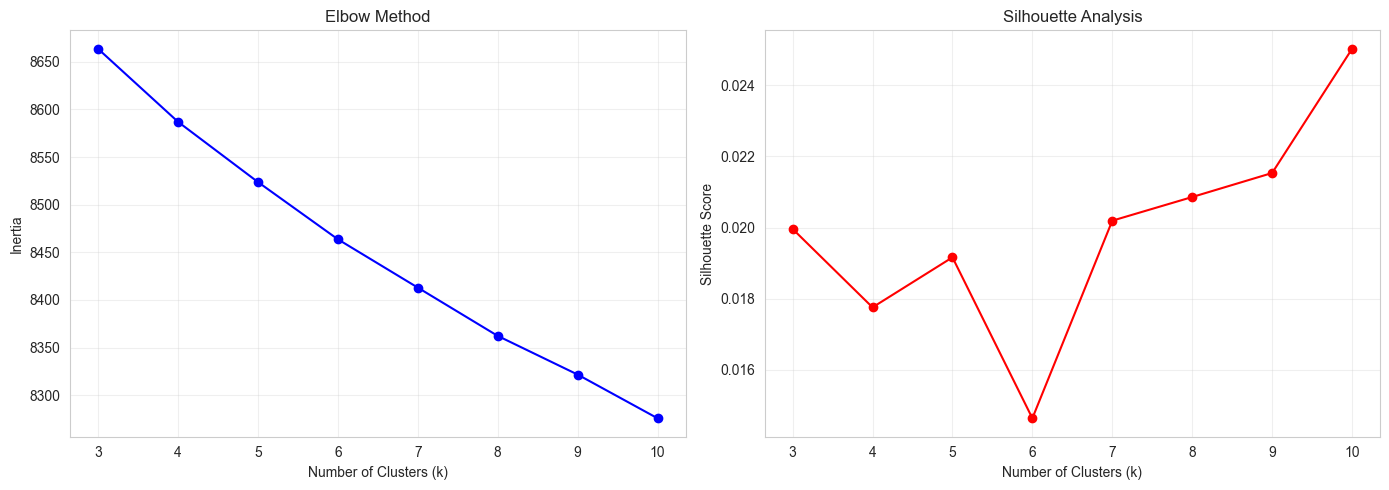


Using k=6 clusters for analysis


In [69]:
# Determine optimal number of clusters using elbow method
from sklearn.metrics import silhouette_score

print("Finding optimal number of clusters...\n")

# Test different numbers of clusters
inertias = []
silhouette_scores = []
k_range = range(3, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(tfidf_matrix, kmeans.labels_, sample_size=1000))
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Use optimal k
optimal_k = 6
print(f"\nUsing k={optimal_k} clusters for analysis")

In [70]:
# Perform final clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_sample['cluster'] = kmeans.fit_predict(tfidf_matrix)

print(f"\nClustering Results")
print("=" * 70)
print(f"\nCluster distribution:")
print(df_sample['cluster'].value_counts().sort_index())

# Get top technical terms for each cluster (filtered)
def get_cluster_top_terms(cluster_id, n_terms=10):
    """
    Get the most important technical terms for a cluster.
    """
    # Get centroid
    centroid = kmeans.cluster_centers_[cluster_id]
    
    # Get all terms sorted by importance
    term_scores = [(feature_names[i], centroid[i]) for i in range(len(centroid))]
    term_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Filter to technical skills only
    technical_terms = []
    for term, score in term_scores:
        normalized_term = normalize_skill(term)
        if is_technical_skill(normalized_term):
            technical_terms.append(term)
            if len(technical_terms) >= n_terms:
                break
    
    return technical_terms

print("\nTop Technical Terms per Cluster (Filtered):")
print("=" * 70)
for i in range(optimal_k):
    print(f"\nCluster {i} (n={len(df_sample[df_sample['cluster']==i])}):")
    print(f"  Top technical terms: {', '.join(get_cluster_top_terms(i))}")
    print(f"  Sample jobs:")
    sample_jobs = df_sample[df_sample['cluster']==i]['job_title'].head(3).values
    for j, job in enumerate(sample_jobs, 1):
        print(f"    {j}. {job}")


Clustering Results

Cluster distribution:
cluster
0     679
1     996
2    1717
3    4175
4    1416
5     645
Name: count, dtype: int64

Top Technical Terms per Cluster (Filtered):

Cluster 0 (n=679):
  Top technical terms: chef, excel, word excel, microsoft excel, forecasting, financial analysis, cpr, express, excel word, excel outlook
  Sample jobs:
    1. Kitchen Prep
    2. Assistant Manager
    3. Assistant General Manager

Cluster 1 (n=996):
  Top technical terms: bls, acls, cpr, bls certification, cpr certification, medication administration, acls certification, current cpr, bls acls, pals
  Sample jobs:
    1. Registered Nurse (RN) at Aveanna
    2. RN Home Health Full Time at Centerwell
    3. Nurse Practitioner-Pediatric Surgery

Cluster 2 (n=1717):
  Top technical terms: bls, acls, emr, cpr, epic, bls certification, cpr certification, phlebotomy, bls acls, pals
  Sample jobs:
    1. Locum | Physician Obstetrics and Gynecology
    2. Travel RN Oncology 1862.00/week - 2373103

In [71]:
# Visualize clusters using dimensionality reduction (t-SNE or PCA)
from sklearn.manifold import TSNE

print("Reducing dimensions for visualization...")
print("This may take a few minutes...\n")

# Use TruncatedSVD first to reduce dimensions before t-SNE
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(tfidf_reduced)

# Add to dataframe
df_sample['tsne_1'] = tsne_results[:, 0]
df_sample['tsne_2'] = tsne_results[:, 1]

# Create interactive plot
fig = px.scatter(df_sample, x='tsne_1', y='tsne_2', 
                color='cluster',
                hover_data=['job_title', 'company', 'job_level'],
                title='Job Clusters Visualization (t-SNE)',
                labels={'cluster': 'Cluster'},
                color_continuous_scale='Viridis')
fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.update_layout(height=700)
fig.show()

print("Visualization complete")

Reducing dimensions for visualization...
This may take a few minutes...



Visualization complete


---
## 8. Topic Modeling (LDA)

Discover hidden themes and patterns in job descriptions to understand market segments.

In [72]:
# Create document-term matrix for LDA
print("Creating document-term matrix for topic modeling...\n")

count_vectorizer = CountVectorizer(
    max_features=3000,
    min_df=5,
    max_df=0.7,
    stop_words='english'
)

doc_term_matrix = count_vectorizer.fit_transform(df_sample['combined_text'])
feature_names_lda = count_vectorizer.get_feature_names_out()

print(f"Document-term matrix shape: {doc_term_matrix.shape}")

# Train LDA model
n_topics = 8
print(f"\nTraining LDA model with {n_topics} topics...")

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=20,
    n_jobs=-1
)

lda_output = lda_model.fit_transform(doc_term_matrix)

print("LDA model trained")

Creating document-term matrix for topic modeling...

Document-term matrix shape: (9628, 3000)

Training LDA model with 8 topics...
LDA model trained


In [73]:
# Display topics (filtered to technical terms only)
def display_topics(model, feature_names, n_top_words=15):
    """
    Display the top technical words for each topic.
    """
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        # Get all words sorted by importance
        word_scores = [(feature_names[i], topic[i]) for i in range(len(topic))]
        word_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Filter to technical skills only
        technical_words = []
        for word, score in word_scores:
            normalized_word = normalize_skill(word)
            if is_technical_skill(normalized_word):
                technical_words.append(word)
                if len(technical_words) >= n_top_words:
                    break
        
        topics.append((topic_idx, technical_words))
    return topics

topics = display_topics(lda_model, feature_names_lda, n_top_words=15)

print("\nDiscovered Topics (Technical Terms Only):")
print("=" * 70)

for topic_idx, top_words in topics:
    print(f"\nTopic {topic_idx}:")
    print(f"  {', '.join(top_words)}")


Discovered Topics (Technical Terms Only):

Topic 0:
  bls, cpr, acls, emr, epic, pals, spring, express, excel, networking, oracle, agile, optimization, salesforce, java

Topic 1:
  chef, express, cpr, spring, excel, agile, forecasting, epic, oracle, optimization, networking, sap, emr, aws, bls

Topic 2:
  excel, autocad, sap, forecasting, optimization, oracle, express, networking, cpr, spring, agile, epic, salesforce, sql, cybersecurity

Topic 3:
  bls, acls, epic, oracle, pals, spring, cpr, excel, emr, networking, forecasting, express, autocad, optimization, agile

Topic 4:
  cpr, excel, chef, spring, bls, express, emr, optimization, networking, epic, forecasting, sap, oracle, devops, pals

Topic 5:
  excel, networking, salesforce, forecasting, express, agile, optimization, spring, epic, sap, oracle, cpr, cybersecurity, chef, autocad

Topic 6:
  agile, sql, aws, azure, python, sap, epic, java, cybersecurity, networking, optimization, oracle, devops, javascript, linux

Topic 7:
  expr

In [74]:
# Assign dominant topic to each document
df_sample['dominant_topic'] = lda_output.argmax(axis=1)

# Visualize topic distribution
topic_dist = df_sample['dominant_topic'].value_counts().sort_index()

fig = px.bar(x=topic_dist.index, y=topic_dist.values,
            labels={'x': 'Topic', 'y': 'Number of Jobs'},
            title='Distribution of Jobs Across Topics',
            color=topic_dist.values,
            color_continuous_scale='Viridis')
fig.update_layout(height=500)
fig.show()

# Show sample jobs for each topic
print("\n" + "="*70)
print("SAMPLE JOBS PER TOPIC")
print("="*70)

for topic_idx in range(n_topics):
    print(f"\nTopic {topic_idx}:")
    print("-" * 50)
    sample_jobs = df_sample[df_sample['dominant_topic'] == topic_idx]['job_title'].head(5).values
    for i, job in enumerate(sample_jobs, 1):
        print(f"  {i}. {job}")


SAMPLE JOBS PER TOPIC

Topic 0:
--------------------------------------------------
  1. Registered Nurse (RN) at Aveanna
  2. RN Home Health Full Time at Centerwell
  3. ICU Registrar (With Anaesthetics)
  4. Nurse Practitioner-Pediatric Surgery
  5. Veterinary Cardiologist - $100,000 Signing Bonus!!

Topic 1:
--------------------------------------------------
  1. Executive Sous Chef
  2. Sous Chef- Wittenberg University
  3. Host
  4. AM- Breakfast Server-Restaurant 1
  5. Shift Manager Full Time Starting from $17.50 to $19.00 based on availability and experience

Topic 2:
--------------------------------------------------
  1. Construction Manager
  2. Survey Project Manager/Project Surveyor -Denver
  3. Buyer Façade
  4. WA State Certified Electrician
  5. Senior Environmental Planner

Topic 3:
--------------------------------------------------
  1. Locum | Physician Obstetrics and Gynecology
  2. Travel RN Oncology 1862.00/week - 23731031EXPPLAT /
  3. Travel Registered Nurse - M

---
## 9. Additional Analysis

Further insights into skill patterns and job description characteristics.

### 9.1 Skill Co-occurrence Analysis

In [75]:
# Analyze which technical skills frequently appear together
from itertools import combinations

# Get skill pairs from technical skills only
skill_pairs = []
for skills_str in df_sample['job_skills'].dropna():
    technical_skills_filtered = sorted(set(extract_technical_skills(skills_str)))
    if len(technical_skills_filtered) >= 2:
        pairs = list(combinations(technical_skills_filtered, 2))
        skill_pairs.extend(pairs)

# Count pair frequency
pair_counts = Counter(skill_pairs)
top_pairs = pair_counts.most_common(20)

print("\nTechnical Skill Co-occurrence Analysis")
print("=" * 70)
print("\nTop 20 Technical Skill Combinations:")
print("-" * 70)
for i, ((skill1, skill2), count) in enumerate(top_pairs, 1):
    print(f"{i:2d}. {skill1:<30} + {skill2:<30} ({count:,} jobs)")


Technical Skill Co-occurrence Analysis

Top 20 Technical Skill Combinations:
----------------------------------------------------------------------
 1. acls                           + bls                            (130 jobs)
 2. acls                           + pals                           (86 jobs)
 3. python                         + sql                            (70 jobs)
 4. bls                            + pals                           (68 jobs)
 5. java                           + python                         (52 jobs)
 6. aws                            + python                         (46 jobs)
 7. acls certification             + bls certification              (44 jobs)
 8. java                           + sql                            (44 jobs)
 9. bls                            + cpr                            (39 jobs)
10. aws                            + java                           (38 jobs)
11. css                            + html                           (3

### 9.2 Text Statistics

Calculating text statistics...


Job Description Text Statistics:
        word_count    char_count  avg_word_length  sentence_count
count  9628.000000   9628.000000      9628.000000     9628.000000
mean    551.029601   3822.652264         5.914323       25.303074
std     322.076062   2266.831720         0.427832       16.822501
min       9.000000     82.000000         1.466714        1.000000
25%     329.000000   2243.000000         5.643363       13.000000
50%     489.000000   3369.000000         5.937049       22.000000
75%     712.000000   4955.750000         6.189487       34.000000
max    3341.000000  23748.000000        15.666667      192.000000


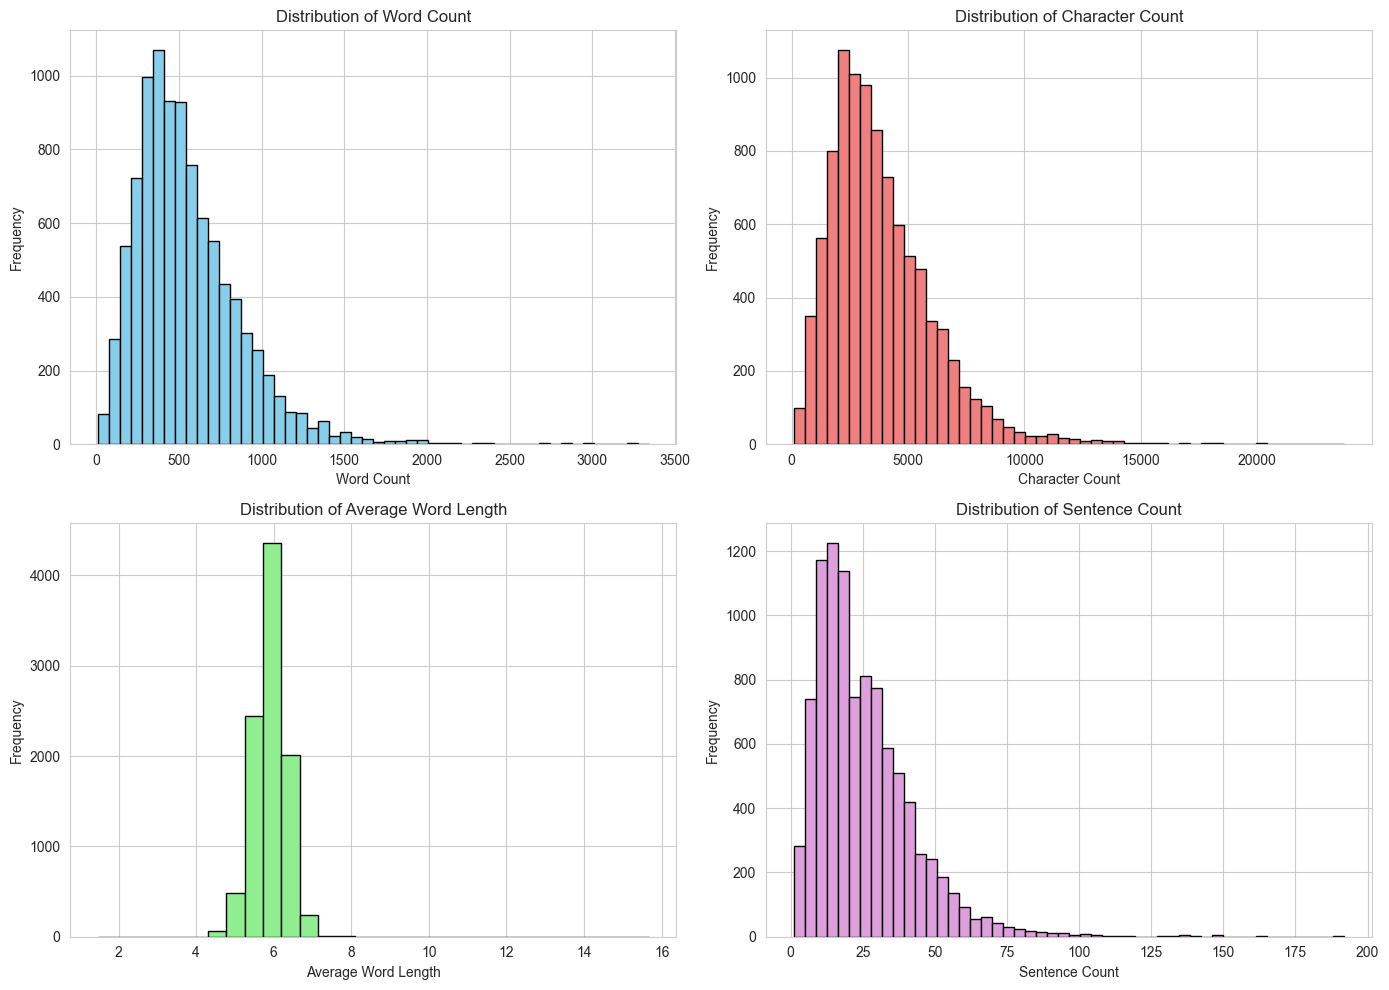

In [76]:
# Analyze text characteristics of job summaries
def get_text_stats(text):
    """
    Calculate various text statistics.
    """
    if pd.isna(text) or not text:
        return {'word_count': 0, 'char_count': 0, 'avg_word_length': 0, 'sentence_count': 0}
    
    words = str(text).split()
    sentences = sent_tokenize(str(text))
    
    return {
        'word_count': len(words),
        'char_count': len(str(text)),
        'avg_word_length': np.mean([len(word) for word in words]) if words else 0,
        'sentence_count': len(sentences)
    }

# Calculate stats
print("Calculating text statistics...\n")
text_stats = df_sample['job_summary'].apply(get_text_stats)
stats_df = pd.DataFrame(text_stats.tolist())

# Summary statistics
print("\nJob Description Text Statistics:")
print("=" * 70)
print(stats_df.describe())

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(stats_df['word_count'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Word Count')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(stats_df['char_count'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribution of Character Count')
axes[0, 1].set_xlabel('Character Count')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(stats_df['avg_word_length'], bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribution of Average Word Length')
axes[1, 0].set_xlabel('Average Word Length')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(stats_df['sentence_count'], bins=50, color='plum', edgecolor='black')
axes[1, 1].set_title('Distribution of Sentence Count')
axes[1, 1].set_xlabel('Sentence Count')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---
## 10. Export Models and Data

In [77]:
# Save processed data and models
import pickle

print("Exporting data and models...\n")

# Create output directory
import os
os.makedirs('output', exist_ok=True)

# Save processed dataset
df_sample.to_csv('output/processed_jobs.csv', index=False)
print("Processed jobs saved to 'output/processed_jobs.csv'")

# Save TF-IDF vectorizer
with open('output/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("TF-IDF vectorizer saved to 'output/tfidf_vectorizer.pkl'")

# Save TF-IDF matrix
with open('output/tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)
print("TF-IDF matrix saved to 'output/tfidf_matrix.pkl'")

# Save LDA model
with open('output/lda_model.pkl', 'wb') as f:
    pickle.dump(lda_model, f)
print("LDA model saved to 'output/lda_model.pkl'")

# Save clustering model
with open('output/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("K-Means model saved to 'output/kmeans_model.pkl'")

# Save skill statistics
skills_df = pd.DataFrame(top_skills[:100], columns=['Skill', 'Count'])
skills_df.to_csv('output/top_skills.csv', index=False)
print("Top skills saved to 'output/top_skills.csv'")

print("\nAll files exported successfully")

Exporting data and models...

Processed jobs saved to 'output/processed_jobs.csv'
TF-IDF vectorizer saved to 'output/tfidf_vectorizer.pkl'
TF-IDF matrix saved to 'output/tfidf_matrix.pkl'
LDA model saved to 'output/lda_model.pkl'
K-Means model saved to 'output/kmeans_model.pkl'
Top skills saved to 'output/top_skills.csv'

All files exported successfully


---
## 12. Export Results for Application

In [78]:
# Save processed data and models for use in the application
import pickle

print("Exporting processed data and models...\n")

# Create output directory
import os
os.makedirs('output', exist_ok=True)

# Save processed dataset
df_sample.to_csv('output/processed_jobs.csv', index=False)
print("Processed jobs saved to 'output/processed_jobs.csv'")

# Save TF-IDF vectorizer
with open('output/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("TF-IDF vectorizer saved to 'output/tfidf_vectorizer.pkl'")

# Save TF-IDF matrix
with open('output/tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)
print("TF-IDF matrix saved to 'output/tfidf_matrix.pkl'")

# Save LDA model
with open('output/lda_model.pkl', 'wb') as f:
    pickle.dump(lda_model, f)
print("LDA model saved to 'output/lda_model.pkl'")

# Save clustering model
with open('output/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("K-Means model saved to 'output/kmeans_model.pkl'")

# Save skill statistics
skills_df = pd.DataFrame(top_skills[:100], columns=['Skill', 'Count'])
skills_df.to_csv('output/top_skills.csv', index=False)
print("Top skills saved to 'output/top_skills.csv'")

print("\nAll files exported successfully")

Exporting processed data and models...

Processed jobs saved to 'output/processed_jobs.csv'
TF-IDF vectorizer saved to 'output/tfidf_vectorizer.pkl'
TF-IDF matrix saved to 'output/tfidf_matrix.pkl'
LDA model saved to 'output/lda_model.pkl'
K-Means model saved to 'output/kmeans_model.pkl'
Top skills saved to 'output/top_skills.csv'

All files exported successfully


---
## 11. Summary

### Key Findings

This analysis identified trending skills and jobs from LinkedIn job postings:

**Trending Skills:**
- Identified the most in-demand skills across job postings
- Analyzed how skill requirements differ by job level
- Found which skills are commonly paired together

**Trending Jobs:**
- Analyzed the most common job roles in the market
- Grouped similar jobs into categories
- Identified top hiring companies and locations

**Market Insights:**
- Discovered hidden topics in job descriptions
- Analyzed common patterns in job requirements
- Identified distinct job market segments

### Files Generated

The following files have been exported for further use:
- `processed_jobs.csv` - Cleaned job data
- `tfidf_vectorizer.pkl` - TF-IDF model
- `tfidf_matrix.pkl` - Feature matrix
- `lda_model.pkl` - Topic model
- `kmeans_model.pkl` - Clustering model
- `top_skills.csv` - Trending skills list

These files can be integrated into applications for job market analysis.

---
**Project:** ITS120L Trending Skills and Jobs Analysis  
**Author:** De Ocampo, James Patrick B.       
**Date:** March 2026